<a href="https://colab.research.google.com/github/Divija062006/Thermal-Leptogenesis-Code/blob/main/Untitled17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  THERMAL LEPTOGENESIS — Coupled Boltzmann Equation Solver

  Choose a mode:

    [1] Run with DEFAULT parameters
        (K=10, ε₁=10⁻⁶, M₁=10¹⁰ GeV, g*=106.75)
        Good for: quick verification, standard strong-washout scenario.

    [2] Enter CUSTOM parameters
        You will be prompted for each physics and numerical parameter.
        Good for: exploring weak/strong washout, different CP asymmetries,
        varying neutrino mass scales, or tuning numerical precision.

  Enter 1 or 2: 1

  >> Using default parameters.

  Parameter Summary

  ┌─── Physics Parameters ────────────────────────────────────────┐
  │  K  (decay parameter)    = 10.0          (strong washout)     │
  │  ε₁ (CP asymmetry)       = 1e-06                                  │
  │  M₁ (RHN mass)           = 1.00e+10 GeV                       │
  │  g* (rel. dof)           = 106.75                                 │
  └───────────────────────────────────────────────────────────────┘
  ┌─── Numerical Parameters ─

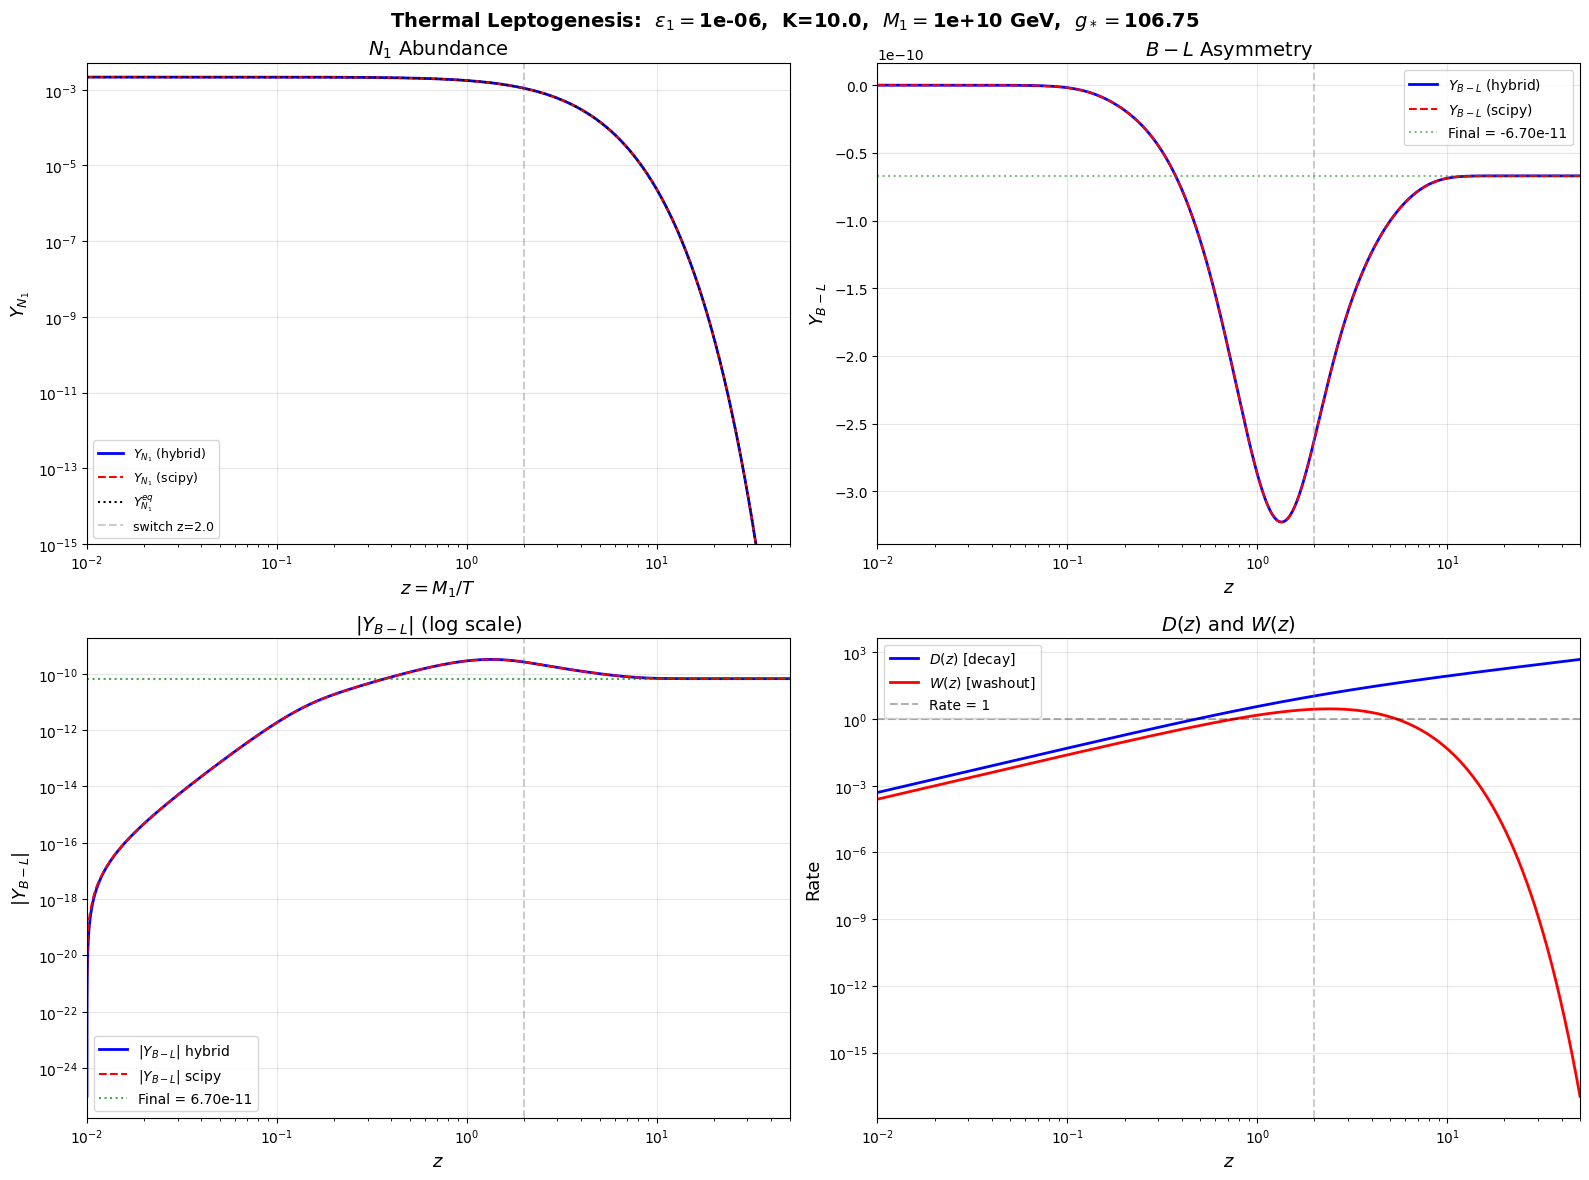

  Saved: leptogenesis_results.png


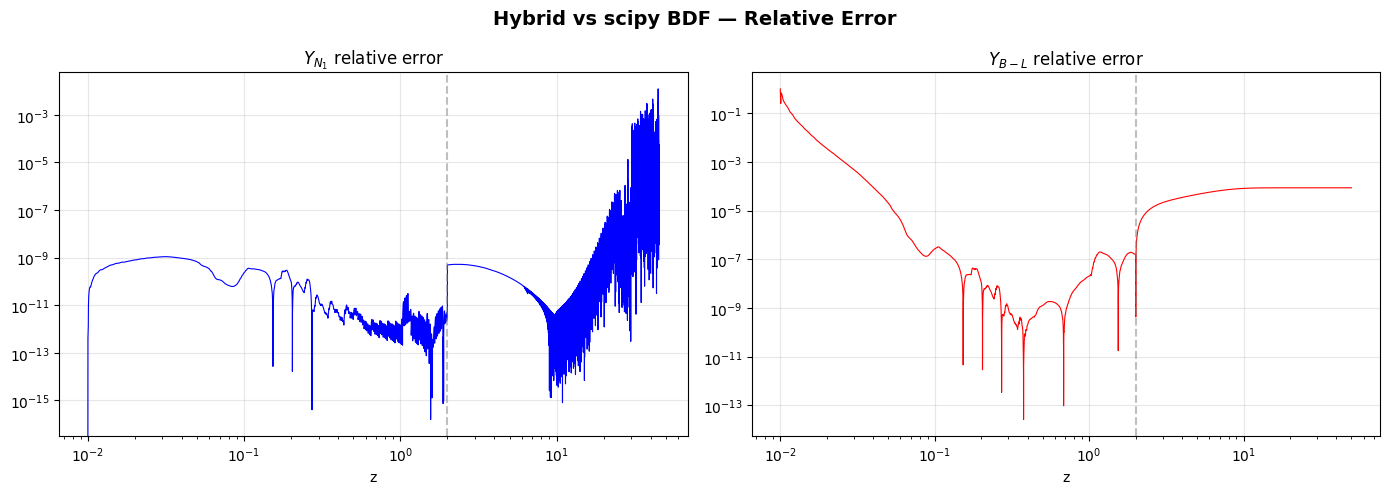

  Saved: leptogenesis_error.png

  SECTION 8: Physical Interpretation

  The Story of Baryogenesis with These Parameters
  ─────────────────────────────────────────────────

  Heavy neutrino mass:  M₁ = 1.00e+10 GeV
  CP violation:         ε₁ = 1e-06
  Washout strength:     K  = 10.0  (strong washout)

  1. HIGH TEMPERATURE (z << 1, T >> M₁):
     N₁ is relativistic and in full thermal equilibrium.
     Y_N₁ = Y_eq ≈ 2.1637e-03.  No B−L asymmetry.

  2. T ~ M₁ (z ~ 1):
     N₁ becomes non-relativistic. Its equilibrium abundance starts
     dropping, but the actual abundance lags behind (Y_N₁ > Y_eq).
     CP-violating decays N₁ → ℓH produce a net B−L asymmetry.

  3. WASHOUT ERA (z ~ 1–5):
     Inverse decays (ℓH → N₁) try to erase the asymmetry.

     With K = 10.0 (strong washout), inverse decays are very efficient.
     Most of the asymmetry generated at z~1 is washed out.
     The surviving asymmetry is generated at z ~ few, just before
     inverse decays freeze out. This is why Y

In [ ]:
"""
================================================================================
  THERMAL LEPTOGENESIS: Boltzmann Equation Solver
  ================================================================================

  Solves the coupled Boltzmann equations for the co-moving number densities
  of the lightest heavy right-handed neutrino (N1) and the B-L asymmetry:

    dY_N1/dz = -D(z) · (Y_N1 / Y_eq - 1)
    dY_BL/dz = -ε₁ · D(z) · (Y_N1 / Y_eq - 1) - W(z) · Y_BL

  where z = M1/T is the dimensionless inverse temperature.

  Methods:
    Primary  — Hybrid RK4 / Implicit Euler (handles stiffness at large z)
    Validate — scipy BDF (implicit multi-step, industry standard for stiff ODEs)

================================================================================
"""

import numpy as np
from scipy.special import kn
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')


#   SECTION 0: MODE SELECTION


print("=" * 72)
print("  THERMAL LEPTOGENESIS — Coupled Boltzmann Equation Solver")
print("=" * 72)
print("""
  Choose a mode:

    [1] Run with DEFAULT parameters
        (K=10, ε₁=10⁻⁶, M₁=10¹⁰ GeV, g*=106.75)
        Good for: quick verification, standard strong-washout scenario.

    [2] Enter CUSTOM parameters
        You will be prompted for each physics and numerical parameter.
        Good for: exploring weak/strong washout, different CP asymmetries,
        varying neutrino mass scales, or tuning numerical precision.
""")

# ── Get user choice ──
mode = input("  Enter 1 or 2: ").strip()
while mode not in ['1', '2']:
    mode = input("  Please enter 1 or 2: ").strip()


#    SECTION 1: PARAMETER SETUP


if mode == '1':
    # ─────────────────────────────────────────────────────────────────
    #  OPTION 1: Default parameters
    # ─────────────────────────────────────────────────────────────────
    print("\n  >> Using default parameters.\n")

    # Physics
    K         = 10.0        # Decay parameter (strong washout)
    epsilon_1 = 1e-6        # CP asymmetry
    M1        = 1e10        # RHN mass [GeV]
    g_star    = 106.75      # SM relativistic dof

    # Numerical
    z_initial = 1e-2        # Start z
    z_final   = 50.0        # End z
    N_grid    = 300000      # Grid points in ln(z)
    rtol      = 1e-10       # scipy relative tolerance
    atol      = 1e-16       # scipy absolute tolerance

else:
    # ─────────────────────────────────────────────────────────────────
    #  OPTION 2: Custom parameters
    # ─────────────────────────────────────────────────────────────────
    print("\n  >> Custom parameter entry.")
    print("     (Press Enter to accept the default shown in brackets.)\n")

    # ── Physics Parameters ──
    print("  ── Physics Parameters (the 'What if?' inputs) ──\n")

    inp = input("    K  — Decay parameter  [10.0]: ").strip()
    K = float(inp) if inp else 10.0

    inp = input("    ε₁ — CP asymmetry     [1e-6]: ").strip()
    epsilon_1 = float(inp) if inp else 1e-6

    inp = input("    M₁ — RHN mass in GeV  [1e10]: ").strip()
    M1 = float(inp) if inp else 1e10

    inp = input("    g* — Relativistic dof  [106.75]: ").strip()
    g_star = float(inp) if inp else 106.75

    # ── Numerical Parameters ──
    print("\n  ── Numerical Parameters (the 'Accuracy' inputs) ──\n")

    inp = input("    z_initial — Start z         [0.01]: ").strip()
    z_initial = float(inp) if inp else 1e-2

    inp = input("    z_final   — End z           [50.0]: ").strip()
    z_final = float(inp) if inp else 50.0

    inp = input("    N_grid    — Grid points     [300000]: ").strip()
    N_grid = int(inp) if inp else 300000

    inp = input("    rtol      — Scipy tolerance [1e-10]: ").strip()
    rtol = float(inp) if inp else 1e-10

    atol = 1e-16  # Fixed; rarely needs changing

    print()

# ── Derived numerical choice: RK4-to-implicit switch ──
z_switch = 2.0 if K >= 5 else 5.0

# ── Print summary ──
print("=" * 72)
print("  Parameter Summary")
print("=" * 72)
print(f"""
  ┌─── Physics Parameters ────────────────────────────────────────┐
  │  K  (decay parameter)    = {K:<12}  {'(strong washout)' if K > 1 else '(weak washout)' if K < 1 else '(transition)'}     │
  │  ε₁ (CP asymmetry)       = {epsilon_1:<12}                           │
  │  M₁ (RHN mass)           = {M1:.2e} GeV                       │
  │  g* (rel. dof)           = {g_star:<12}                           │
  └───────────────────────────────────────────────────────────────┘
  ┌─── Numerical Parameters ──────────────────────────────────────┐
  │  z range                 = [{z_initial}, {z_final}]                          │
  │  Grid points             = {N_grid:<12}                           │
  │  d(ln z)                 = {np.log(z_final/z_initial)/N_grid:.6e}                      │
  │  scipy rtol              = {rtol:<12}                           │
  │  RK4 → implicit at       = z = {z_switch:<8}                        │
  └───────────────────────────────────────────────────────────────┘
""")


#    SECTION 2: DERIVED QUANTITIES & AUXILIARY FUNCTIONS


print("=" * 72)
print("  SECTION 2: Derived Quantities")
print("=" * 72)

# ── Fundamental constants ──
M_Pl = 1.22e19    # Planck mass [GeV]
v_EW = 246.0      # Electroweak VEV [GeV]

# ── Hubble rate at T = M1 ──
H_M1 = np.sqrt(8.0 * np.pi**3 * g_star / 90.0) * M1**2 / M_Pl

# ── N1 decay width ──
Gamma_N1 = K * H_M1

# ── Equilibrium neutrino mass ──
m_star  = 16 * np.pi * v_EW**2 * np.sqrt(g_star) / (3 * np.sqrt(5.0) * M_Pl)
m_tilde = K * m_star

print(f"  H(T=M₁)       = {H_M1:.4e} GeV")
print(f"  Γ_N₁ = K·H    = {Gamma_N1:.4e} GeV")
print(f"  m* (eq. mass)  = {m_star*1e9:.4f} × 10⁻³ eV")
print(f"  m̃ = K·m*       = {m_tilde*1e9:.4f} × 10⁻³ eV")

# ── Equilibrium abundance prefactor ──
_pf = 45.0 / (4.0 * np.pi**4 * g_star)

# ── Auxiliary functions ──

def Y_eq(z):
    """Equilibrium N1 abundance: (45/4π⁴g*) z² K₂(z)"""
    return _pf * z**2 * kn(2, z)

def Y_eq_vec(za):
    return _pf * za**2 * kn(2, za)

def D_func(z):
    """Decay term: K z K₁(z)/K₂(z)"""
    K2 = kn(2, z)
    return K * z * kn(1, z) / K2 if K2 > 1e-300 else K * z

def W_func(z):
    """Washout: (1/4) K z³ K₁(z)"""
    return 0.25 * K * z**3 * kn(1, z)

def D_vec(za):
    K1 = kn(1, za); K2 = kn(2, za)
    m = K2 > 1e-300; r = np.zeros_like(za, dtype=float)
    r[m] = K * za[m] * K1[m] / K2[m]; r[~m] = K * za[~m]
    return r

def W_vec(za):
    return 0.25 * K * za**3 * kn(1, za)

# ── Table of function values ──
print(f"\n  {'z':>6} | {'Y_eq':>12} | {'D(z)':>10} | {'W(z)':>12} | {'Stiffness D/Y_eq':>18}")
print("  " + "-" * 68)
for zv in [z_initial, 0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0]:
    if zv > z_final: break
    Yeq = Y_eq(zv); Dz = D_func(zv); Wz = W_func(zv)
    lam = Dz / Yeq if Yeq > 1e-300 else float('inf')
    print(f"  {zv:6.2f} | {Yeq:12.4e} | {Dz:10.4f} | {Wz:12.4e} | {lam:18.2e}")


#   SECTION 3: THE BOLTZMANN EQUATIONS


print("\n" + "=" * 72)
print("  SECTION 3: The Coupled Boltzmann Equations")
print("=" * 72)
print(f"""
  Equation 1 — N₁ abundance:
    dY_N₁/dz = −D(z) · (Y_N₁/Y_eq − 1)

  Equation 2 — B−L asymmetry:
    dY_BL/dz = −ε₁ · D(z) · (Y_N₁/Y_eq − 1) − W(z) · Y_BL

  Auxiliary:
    D(z) = K · z · K₁(z)/K₂(z)       [decay/inverse-decay rate]
    W(z) = ¼ · K · z³ · K₁(z)         [washout rate]
    Y_eq = (45/4π⁴g*) · z² · K₂(z)   [equilibrium abundance]

  Stiffness: D/Y_eq grows as exp(z). Pure RK4 fails for z > ~2.
  Solution:  RK4 for z < {z_switch},  implicit Euler for z ≥ {z_switch}.
""")

def boltzmann_rhs(z, yn1, ybl):
    """RHS of the coupled Boltzmann equations."""
    K1 = kn(1, z); K2 = kn(2, z)
    Yeq = _pf * z**2 * K2
    Dz = K * z * K1 / K2 if K2 > 1e-300 else K * z
    Wz = 0.25 * K * z**3 * K1

    if Yeq > 1e-300:
        dev = yn1 / Yeq - 1.0
    elif yn1 < 1e-250:
        dev = 0.0
    else:
        dev = min(yn1 / max(Yeq, 1e-300) - 1.0, 1e12)

    dyn1 = -Dz * dev
    dybl = -epsilon_1 * Dz * dev - Wz * ybl
    return dyn1, dybl


#    SECTION 4: HYBRID SOLVER


print("=" * 72)
print("  SECTION 4: Solving — Hybrid RK4 / Implicit Euler")
print("=" * 72)

# ── Grid ──
t_grid   = np.linspace(np.log(z_initial), np.log(z_final), N_grid + 1)
z_grid   = np.exp(t_grid)
Yeq_grid = Y_eq_vec(z_grid)

# ── Initial conditions ──
Y_N1_0 = Y_eq(z_initial)
Y_BL_0 = 0.0
i_switch = np.searchsorted(z_grid, z_switch)

print(f"\n  Initial conditions:")
print(f"    Y_N₁(z_i) = Y_eq(z_i) = {Y_N1_0:.6e}")
print(f"    Y_BL(z_i)              = 0")
print(f"\n  Phase 1 (RK4):      {i_switch:,} steps, z ∈ [{z_initial}, {z_grid[i_switch]:.4f}]")
print(f"  Phase 2 (Implicit): {N_grid - i_switch:,} steps, z ∈ [{z_grid[i_switch]:.4f}, {z_final}]")

# ── Storage ──
YN1 = np.zeros(N_grid + 1)
YBL = np.zeros(N_grid + 1)
YN1[0] = Y_N1_0
YBL[0] = Y_BL_0

# ── Phase 1: RK4 ──
print(f"\n  Phase 1 (RK4)... ", end="", flush=True)
t0 = time.time()

for i in range(i_switch):
    z_n = z_grid[i]
    dz  = z_grid[i + 1] - z_grid[i]
    yn1 = YN1[i]; ybl = YBL[i]

    k1a, k1b = boltzmann_rhs(z_n,        yn1,             ybl)
    k2a, k2b = boltzmann_rhs(z_n + dz/2, yn1 + dz/2*k1a, ybl + dz/2*k1b)
    k3a, k3b = boltzmann_rhs(z_n + dz/2, yn1 + dz/2*k2a, ybl + dz/2*k2b)
    k4a, k4b = boltzmann_rhs(z_n + dz,   yn1 + dz*k3a,   ybl + dz*k3b)

    YN1[i+1] = yn1 + (dz/6) * (k1a + 2*k2a + 2*k3a + k4a)
    YBL[i+1] = ybl + (dz/6) * (k1b + 2*k2b + 2*k3b + k4b)

t_rk4 = time.time() - t0
print(f"Done ({t_rk4:.2f}s)")

# ── Phase 2: Implicit Backward Euler ──
#
#  Y_N1: Analytic implicit solve
#    Y_N1^{n+1} = (Y_N1^n + dz·D) / (1 + dz·D/Y_eq)
#
#  Y_BL: Implicit washout, explicit source
#    Y_BL^{n+1} = (Y_BL^n + dz·source) / (1 + dz·W)

print(f"  Phase 2 (Implicit)... ", end="", flush=True)
t0 = time.time()

for i in range(i_switch, N_grid):
    z_np1 = z_grid[i + 1]
    dz    = z_np1 - z_grid[i]

    K1_z = kn(1, z_np1); K2_z = kn(2, z_np1)
    Yeq  = _pf * z_np1**2 * K2_z
    Dz   = K * z_np1 * K1_z / K2_z if K2_z > 1e-300 else K * z_np1
    Wz   = 0.25 * K * z_np1**3 * K1_z

    # Implicit Y_N1
    if Yeq > 1e-300:
        yn1_new = (YN1[i] + dz * Dz) / (1.0 + dz * Dz / Yeq)
    else:
        yn1_new = 0.0
    yn1_new = max(yn1_new, 0.0)

    # Source for Y_BL
    dev = (yn1_new / Yeq - 1.0) if Yeq > 1e-300 else 0.0
    source = -epsilon_1 * Dz * dev

    # Implicit Y_BL
    ybl_new = (YBL[i] + dz * source) / (1.0 + dz * Wz)

    YN1[i + 1] = yn1_new
    YBL[i + 1] = ybl_new

t_impl = time.time() - t0
print(f"Done ({t_impl:.2f}s)")
print(f"  Total solve time: {t_rk4 + t_impl:.2f}s")


#    SECTION 5: SCIPY BDF CROSS-VALIDATION


print("\n" + "=" * 72)
print("  SECTION 5: Cross-Validation (scipy BDF)")
print("=" * 72)

def sys_scipy(z, Y):
    d1, d2 = boltzmann_rhs(z, Y[0], Y[1])
    return [d1, d2]

print(f"  Tolerances: rtol = {rtol}, atol = {atol}")
print("  Running... ", end="", flush=True)
t0 = time.time()

sol = solve_ivp(sys_scipy, [z_initial, z_final], [Y_N1_0, 0.0],
                method='BDF', t_eval=z_grid, rtol=rtol, atol=atol)
YN1_sci = sol.y[0]
YBL_sci = sol.y[1]

t_sci = time.time() - t0
print(f"{'Done' if sol.success else 'Warning: ' + sol.message} "
      f"({t_sci:.2f}s, {sol.nfev} evaluations)")


#    SECTION 6: RESULTS


print("\n" + "=" * 72)
print("  SECTION 6: Results")
print("=" * 72)

YBL_f_hyb = YBL[-1]
YBL_f_sci = YBL_sci[-1]
rdiff = abs(YBL_f_hyb - YBL_f_sci) / abs(YBL_f_sci) * 100 if abs(YBL_f_sci) > 1e-300 else 0

a_sph   = 28.0 / 79.0
Y_B_hyb = a_sph * YBL_f_hyb
Y_B_sci = a_sph * YBL_f_sci
Y_B_obs = 8.7e-11

print(f"""
  ╔═══════════════════════════════════════════════════════════════╗
  ║                 FINAL RESULTS  (z = {z_final:<6})             ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║                                                               ║
  ║  Method          │  Y_N₁(z_f)       │  Y_BL(z_f)              ║
  ║  ────────────────┼──────────────────┼──────────────────       ║
  ║  Hybrid RK4/Impl │ {YN1[-1]:>16.6e} │ {YBL_f_hyb:>16.6e}      ║
  ║  scipy BDF       │ {YN1_sci[-1]:>16.6e} │ {YBL_f_sci:>16.6e}  ║
  ║                                                               ║
  ║  Agreement: ΔY_BL/Y_BL = {rdiff:.4f}%                         ║
  ║                                                               ║
  ╠═══════════════════════════════════════════════════════════════╣
  ║                                                               ║
  ║  Baryon Asymmetry  (Y_B = 28/79 · Y_BL, sphaleron conversion) ║
  ║                                                               ║
  ║    |Y_B| predicted   = {abs(Y_B_sci):.6e}                     ║
  ║    |Y_B| observed     = 8.7 × 10⁻¹¹  (Planck CMB)             ║
  ║    Ratio pred/obs     = {abs(Y_B_sci)/Y_B_obs:.4f}            ║
  ║                                                               ║
  ╚═══════════════════════════════════════════════════════════════╝
""")

# ── Evolution Table ──
kz = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0,
      10.0, 15.0, 20.0, 30.0, 50.0, 80.0, 100.0]
kz = [z for z in kz if z_initial <= z <= z_final]

print("  Evolution Table:")
print("  " + "-" * 88)
print(f"  {'z':>8} | {'Y_N1':>12} | {'Y_eq':>12} | {'Y_N1/Y_eq-1':>12} | "
      f"{'Y_BL(hyb)':>13} | {'Y_BL(sci)':>13}")
print("  " + "-" * 88)
for zv in kz:
    i = np.argmin(np.abs(z_grid - zv))
    yn1 = YN1[i]; yeq = Yeq_grid[i]; ybl_h = YBL[i]; ybl_s = YBL_sci[i]
    dev = (yn1/yeq - 1) if yeq > 1e-300 else 0.0
    tag = "RK4" if z_grid[i] < z_switch else "imp"
    print(f"  {z_grid[i]:8.4f} | {yn1:12.4e} | {yeq:12.4e} | "
          f"{dev:+12.4e} | {ybl_h:+13.4e} | {ybl_s:+13.4e}  [{tag}]")
print("  " + "-" * 88)


#    SECTION 7: PLOTS


print("\n  Generating plots...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    r'Thermal Leptogenesis:  $\epsilon_1=$' + f'{epsilon_1},  K={K},  '
    + r'$M_1=$' + f'{M1:.0e} GeV,  ' + r'$g_*=$' + f'{g_star}',
    fontsize=14, fontweight='bold')

# 1) Y_N1
ax = axes[0, 0]
m1 = YN1 > 1e-20; m2 = YN1_sci > 1e-20; me = Yeq_grid > 1e-20
ax.semilogy(z_grid[m1], YN1[m1], 'b-', lw=2, label=r'$Y_{N_1}$ (hybrid)')
ax.semilogy(z_grid[m2], YN1_sci[m2], 'r--', lw=1.5, label=r'$Y_{N_1}$ (scipy)')
ax.semilogy(z_grid[me], Yeq_grid[me], 'k:', lw=1.5, label=r'$Y_{N_1}^{eq}$')
ax.axvline(z_switch, color='gray', ls='--', alpha=0.4, label=f'switch z={z_switch}')
ax.set_xlabel(r'$z = M_1/T$', fontsize=13)
ax.set_ylabel(r'$Y_{N_1}$', fontsize=13)
ax.set_title(r'$N_1$ Abundance', fontsize=14)
ax.set_xscale('log'); ax.set_xlim(z_initial, z_final); ax.set_ylim(1e-15, 5e-3)
ax.legend(fontsize=9, loc='lower left'); ax.grid(True, alpha=0.3)

# 2) Y_BL linear
ax = axes[0, 1]
ax.plot(z_grid, YBL, 'b-', lw=2, label=r'$Y_{B-L}$ (hybrid)')
ax.plot(z_grid, YBL_sci, 'r--', lw=1.5, label=r'$Y_{B-L}$ (scipy)')
ax.axhline(YBL_f_sci, color='g', ls=':', alpha=0.5, label=f'Final = {YBL_f_sci:.2e}')
ax.axvline(z_switch, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'$z$', fontsize=13); ax.set_ylabel(r'$Y_{B-L}$', fontsize=13)
ax.set_title(r'$B-L$ Asymmetry', fontsize=14)
ax.set_xscale('log'); ax.set_xlim(z_initial, z_final)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='scientific', scilimits=(-3, 3))

# 3) |Y_BL| log
ax = axes[1, 0]
ab1 = np.abs(YBL); ab2 = np.abs(YBL_sci)
m1 = ab1 > 1e-30; m2 = ab2 > 1e-30
ax.semilogy(z_grid[m1], ab1[m1], 'b-', lw=2, label=r'$|Y_{B-L}|$ hybrid')
ax.semilogy(z_grid[m2], ab2[m2], 'r--', lw=1.5, label=r'$|Y_{B-L}|$ scipy')
ax.axhline(abs(YBL_f_sci), color='g', ls=':', alpha=0.7,
           label=f'Final = {abs(YBL_f_sci):.2e}')
ax.axvline(z_switch, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'$z$', fontsize=13); ax.set_ylabel(r'$|Y_{B-L}|$', fontsize=13)
ax.set_title(r'$|Y_{B-L}|$ (log scale)', fontsize=14)
ax.set_xscale('log'); ax.set_xlim(z_initial, z_final)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# 4) D(z) and W(z)
ax = axes[1, 1]
Dp = D_vec(z_grid); Wp = W_vec(z_grid)
ax.semilogy(z_grid, Dp, 'b-', lw=2, label=r'$D(z)$ [decay]')
ax.semilogy(z_grid[Wp > 0], Wp[Wp > 0], 'r-', lw=2, label=r'$W(z)$ [washout]')
ax.axhline(1, color='k', ls='--', alpha=0.3, label='Rate = 1')
ax.axvline(z_switch, color='gray', ls='--', alpha=0.4)
ax.set_xlabel(r'$z$', fontsize=13); ax.set_ylabel('Rate', fontsize=13)
ax.set_title(r'$D(z)$ and $W(z)$', fontsize=14)
ax.set_xscale('log'); ax.set_xlim(z_initial, z_final)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('leptogenesis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: leptogenesis_results.png")

# ── Error plot ──
fig2, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Hybrid vs scipy BDF — Relative Error', fontsize=14, fontweight='bold')

mb = (YN1 > 1e-20) & (YN1_sci > 1e-20)
if np.any(mb):
    a1.semilogy(z_grid[mb],
                np.abs(YN1[mb] - YN1_sci[mb]) / np.abs(YN1_sci[mb]),
                'b-', lw=0.8)
    a1.axvline(z_switch, color='gray', ls='--', alpha=0.5)
a1.set_title(r'$Y_{N_1}$ relative error'); a1.set_xlabel('z')
a1.set_xscale('log'); a1.grid(True, alpha=0.3)

mb2 = (np.abs(YBL) > 1e-25) & (np.abs(YBL_sci) > 1e-25)
if np.any(mb2):
    a2.semilogy(z_grid[mb2],
                np.abs(YBL[mb2] - YBL_sci[mb2]) / np.abs(YBL_sci[mb2]),
                'r-', lw=0.8)
    a2.axvline(z_switch, color='gray', ls='--', alpha=0.5)
a2.set_title(r'$Y_{B-L}$ relative error'); a2.set_xlabel('z')
a2.set_xscale('log'); a2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('leptogenesis_error.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: leptogenesis_error.png")


#   SECTION 8: PHYSICAL INTERPRETATION

print("\n" + "=" * 72)
print("  SECTION 8: Physical Interpretation")
print("=" * 72)

regime = 'strong' if K > 1 else 'weak' if K < 1 else 'transition'

print(f"""
  The Story of Baryogenesis with These Parameters
  ─────────────────────────────────────────────────

  Heavy neutrino mass:  M₁ = {M1:.2e} GeV
  CP violation:         ε₁ = {epsilon_1}
  Washout strength:     K  = {K}  ({regime} washout)

  1. HIGH TEMPERATURE (z << 1, T >> M₁):
     N₁ is relativistic and in full thermal equilibrium.
     Y_N₁ = Y_eq ≈ {Y_eq(z_initial):.4e}.  No B−L asymmetry.

  2. T ~ M₁ (z ~ 1):
     N₁ becomes non-relativistic. Its equilibrium abundance starts
     dropping, but the actual abundance lags behind (Y_N₁ > Y_eq).
     CP-violating decays N₁ → ℓH produce a net B−L asymmetry.

  3. WASHOUT ERA (z ~ 1–5):
     Inverse decays (ℓH → N₁) try to erase the asymmetry.
""")
if K > 1:
    print(f"     With K = {K} (strong washout), inverse decays are very efficient.")
    print(f"     Most of the asymmetry generated at z~1 is washed out.")
    print(f"     The surviving asymmetry is generated at z ~ few, just before")
    print(f"     inverse decays freeze out. This is why Y_BL peaks then dips.")
else:
    print(f"     With K = {K} (weak washout), inverse decays are inefficient.")
    print(f"     Most of the asymmetry generated at z~1 survives intact.")

print(f"""
  4. FREEZE-OUT (z >> 5):
     Inverse decays are Boltzmann-suppressed: W(z) ~ exp(−z) → 0.
     Y_BL freezes at its final value: {YBL_f_sci:.4e}

  5. SPHALERON CONVERSION:
     Before the electroweak phase transition (T ~ 100 GeV),
     sphaleron processes partially convert the lepton asymmetry
     into a baryon asymmetry:

       Y_B = (28/79) × Y_BL = {Y_B_sci:.4e}

     Observed (Planck):  |Y_B| = 8.7 × 10⁻¹¹
     Our prediction:     |Y_B| = {abs(Y_B_sci):.4e}
     Ratio:              {abs(Y_B_sci)/Y_B_obs:.4f}
""")

if 0.1 < abs(Y_B_sci)/Y_B_obs < 10:
    print("  ✓ The prediction is within an order of magnitude of observation!")
    print("    Fine-tuning K and ε₁ can bring this to exact agreement.")
elif abs(Y_B_sci)/Y_B_obs > 10:
    print("  ⚠ Over-production. Try increasing K (more washout) or decreasing ε₁.")
else:
    print("  ⚠ Under-production. Try decreasing K (less washout) or increasing ε₁.")

# ── Final summary ──
print("\n" + "=" * 72)
print("  COMPLETE SUMMARY")
print("=" * 72)
print(f"  Physics:  K = {K},  ε₁ = {epsilon_1},  M₁ = {M1:.2e} GeV,  g* = {g_star}")
print(f"  Numerics: z ∈ [{z_initial}, {z_final}],  {N_grid} grid pts,  rtol = {rtol}")
print(f"  Solve:    RK4 (z<{z_switch}) + implicit (z≥{z_switch}), scipy BDF validation")
print(f"  Result:   |Y_BL| = {abs(YBL_f_hyb):.6e} (hybrid)  |  {abs(YBL_f_sci):.6e} (scipy)")
print(f"            |Y_B|  = {abs(Y_B_sci):.6e}  (pred/obs = {abs(Y_B_sci)/Y_B_obs:.4f})")
print(f"            Agreement: {rdiff:.4f}%")
print("=" * 72)